<font size=8> Chapter 6: Queue and Stack</font>

```python
def mono_stack(insert_entries):
    stack = []
    for entry in insert_entries:
        while(if) stack and stack[-1] <= entry:
            stack.pop()
            # Do something with the popped item here
        stack.append(entry)

from collections import deque
def queue_prob(): 
    queue = deque()
    result = []
    queue.append(root)
    while not all(item is None for item in queue):
        node = queue.popleft()

    return result

```

# Stack design

## Leetcode 1381. Design a Stack With Increment Operation (Medium)

Design a stack that supports increment operations on its elements.

Implement the CustomStack class:

- CustomStack(int maxSize) Initializes the object with maxSize which is the maximum number of elements in the stack.
- void push(int x) Adds x to the top of the stack if the stack has not reached the maxSize.
- int pop() Pops and returns the top of the stack or -1 if the stack is empty.
- void inc(int k, int val) Increments the bottom k elements of the stack by val. If there are less than k elements in the stack, increment all the elements in the stack.
 

Example 1:

- Input

["CustomStack","push","push","pop","push","push","push","increment","increment","pop","pop","pop","pop"]

[[3],[1],[2],[],[2],[3],[4],[5,100],[2,100],[],[],[],[]]

- Output

[null,null,null,2,null,null,null,null,null,103,202,201,-1]

Explanation
CustomStack stk = new CustomStack(3); // Stack is Empty []

stk.push(1);                          // stack becomes [1]

stk.push(2);                          // stack becomes [1, 2]

stk.pop();                            // return 2 --> Return top of the stack 2, stack becomes [1]

stk.push(2);                          // stack becomes [1, 2]

stk.push(3);                          // stack becomes [1, 2, 3]

stk.push(4);                          // stack still [1, 2, 3], Do not add another elements as size is 4

stk.increment(5, 100);                // stack becomes [101, 102, 103]

stk.increment(2, 100);                // stack becomes [201, 202, 103]

stk.pop();                            // return 103 --> Return top of the stack 103, stack becomes [201, 202]

stk.pop();                            // return 202 --> Return top of the stack 202, stack becomes [201]

stk.pop();                            // return 201 --> Return top of the stack 201, stack becomes []

stk.pop();                            // return -1 --> Stack is empty return -1.
 

ideas :

The straightforward approach would be to use a simple array to simulate the stack and directly modify elements during the increment operation. However, this would make the increment operation O(k) in time complexity, as we'd need to iterate through and update k elements.

The key insight is that we can defer the actual increments until we need to access the elements.

Instead of immediately applying the increment to all k elements, we can just "mark" that an increment needs to be applied. We use a separate array add where add[i] stores the cumulative increment that should be applied to the element at position i when it's accessed.

The clever part comes with how we handle these increments during the pop operation. When we pop an element at position i, we:

- Apply the increment stored at add[i] to get the actual value
- Pass this increment down to the element below it (add[i-1] += add[i])
- Clear the increment at position i since we've already used it

In [ ]:
# lazy popu
class CustomStack():
    def __init__(self, maxSize):
        self.stack = [0] * maxSize
        self.add = [0] * maxSize
        self.maxSize = maxSize
        self.length = 0

    def push(self, n):
        if self.length < self.maxSize:
            self.stack[self.length] = n
            self.length += 1

    def pop(self):
        if self.length > 0:
            sol = self.stack[self.length-1] + self.add[self.length-1]
            self.length -= 1
            if self.length > 0:
                self.add[self.length-1] += self.add[self.length]
            return sol
        else:
            return -1 

    def increment(self,k, val):
        index = min(k-1, self.length-1)
        if index >= 0:
            self.add[index] += val

In [ ]:
customStack = CustomStack(3);
customStack.push(1)
customStack.push(2)
customStack.pop()

In [ ]:
customStack.push(2)  
customStack.push(3)    
customStack.push(4)      
customStack.increment(5, 100)
customStack.increment(2, 100) 
customStack.pop()
customStack.pop()
customStack.pop()
customStack.pop()

## Leetcode 155. Min Stack (Medium)

Description:
Design a stack that supports push, pop, top, and retrieving the minimum element in constant time.

push(x) -- Push element x onto stack.
pop( ) -- Removes the element on top of the stack.
top( ) -- Get the top element.
getMin( ) -- Retrieve the minimum element in the stack.

- Example:
Input:

["MinStack","push","push","push","getMin","pop","top","getMin"]

[ [ ],[-2],[0],[-3],[ ],[ ],[ ],[ ] ]

Output:

[null,null,null,null,-3,null,0,-2]

In [ ]:
import math
class MinStack():
    def __init__(self):
        self.stack = []
        self.stack_min = [math.inf]
    def push(self, num):
        self.stack.append(num)
        self.stack_min.append(min(num, self.stack_min[-1]))
    def pop(self):
        if len(self.stack)>0:
            self.stack.pop()
            self.stack_min.pop()
    def getMin(self):
        return self.stack_min[-1]
    def top(self):
        return self.stack[-1]       

In [ ]:
minstack = MinStack()
minstack = MinStack()
minstack.push(-2)
minstack.push(0)
minstack.push(-3)
minstack.getMin()

In [ ]:
minstack.pop()
minstack.top()

In [ ]:
minstack.getMin()

## Leetcode 716. Max Stack
Design a max stack that supports push, pop, top, peekMax and popMax.

push(x) -- Push element x onto stack.
pop() -- Remove the element on top of the stack and return it.
top() -- Get the element on the top.
peekMax() -- Retrieve the maximum element in the stack.
popMax() -- Retrieve the maximum element in the stack, and remove it. If you find more than one maximum elements, only remove the top-most one.
- Example 1:
```
MaxStack stack = new MaxStack();
stack.push(5);
stack.push(1);
stack.push(5);
stack.top(); -> 5
stack.popMax(); -> 5
stack.top(); -> 1
stack.peekMax(); -> 5
stack.pop(); -> 1
stack.top(); -> 5
```

## Leetcode 232. Implement Queue using Stacks

Description:
Implement the following operations of a queue using stacks.

push(x) -- Push element x to the back of queue.

pop() -- Removes the element from in front of queue.

peek() -- Get the front element.

empty() -- Return whether the queue is empty.

Note:
You must use only standard operations of a stack -- which means only push to top, peek/pop from top, size, and is empty operations are valid.
Depending on your language, stack may not be supported natively. You may simulate a stack by using a list or deque (double-ended queue), as long as you use only standard operations of a stack.
You may assume that all operations are valid (for example, no pop or peek operations will be called on an empty queue).

Example 1:

Input
["MyQueue", "push", "push", "peek", "pop", "empty"]

[[], [1], [2], [], [], []]

Output
[null, null, null, 1, 1, false]

Explanation

MyQueue myQueue = new MyQueue();

myQueue.push(1); // queue is: [1]

myQueue.push(2); // queue is: [1, 2] (leftmost is front of the queue)

myQueue.peek(); // return 1

myQueue.pop(); // return 1, queue is [2]

myQueue.empty(); // return false

In [64]:
class MyQueue():
    def __init__(self):
        self.stack1 = []
        self.stack2 = []
    def push(self, num):
        self.stack1.append(num)
    def move(self):
        if not self.stack2:
            while self.stack1:
                self.stack2.append(self.stack1.pop())
    def pop(self):
        self.move()
        return self.stack2.pop()
    def top(self):
        self.move()
        return self.stack2.top()
    def peek(self):
        self.move()
        return self.stack2[-1]
    def empty(self):
        return (not self.stack1) and (not self.stack2)

In [65]:
myQueue = MyQueue()
myQueue.push(1)
myQueue.push(2)
myQueue.peek()

1

In [66]:
myQueue.pop()

1

In [67]:
myQueue.empty()

False

In [96]:
class MyQueue():
    def __init__(self):
        self.stack1 = []
        self.stack2 = []
    def push(self, num):
        self.stack1.append(num)
    def pop(self):
        self.move()
        return self.stack2.pop()
    def peek(self):
        self.move()
        return self.stack2[-1]
    def empty(self):
        return not self.stack1 and not self.stack2
    def move(self):
        if not self.stack2:
            while self.stack1:
                self.stack2.append(self.stack1.pop())

In [97]:
myQueue = MyQueue()
myQueue.push(1)
myQueue.push(2)
myQueue.peek()

1

In [98]:
myQueue.pop()

1

In [99]:
myQueue.empty()

False

# monotonic stack

## Leetcode 496. Next Greater Element I

Description:
You are given two arrays (without duplicates) nums1 and nums2 where nums1’s elements are subset of nums2. Find all the next greater numbers for nums1’s elements in the corresponding places of nums2.

The Next Greater Number of a number x in nums1 is the first greater number to its right in nums2. If it does not exist, output -1 for this number.

Note:
All elements in nums1 and nums2 are unique.
The length of both nums1 and nums2 would not exceed 1000.

- Example1:
Input: nums1 = [4,1,2], nums2 = [1,3,4,2].

Output: [-1,3,-1]

Explanation:

For number 4 in the first array, you cannot find the next greater number for it in the second array, so output -1.
For number 1 in the first array, the next greater number for it in the second array is 3.
For number 2 in the first array, there is no next greater number for it in the second array, so output -1.

- Example2:
Input: nums1 = [2,4], nums2 = [1,2,3,4].

Output: [3,-1]

Explanation:

For number 2 in the first array, the next greater number for it in the second array is 3.
For number 4 in the first array, there is no next greater number for it in the second array, so output -1.

In [25]:
def nextGreaterElement(nums1, nums2):
    stack = []
    myDict = {}
    for num in nums2[::-1]:
        while stack and stack[-1] < num:
            stack.pop()
        if stack:
            myDict[num] = stack[-1]
        stack.append(num)
    return [myDict.get(num, -1) for num in nums1]

In [26]:
nextGreaterElement([4,1,2],[1,3,4,2])

[-1, 3, -1]

In [27]:
nextGreaterElement([2,4],[1,2,3,4])

[3, -1]

In [84]:
def nextGreaterElement(nums1, nums2):
    stack = []
    myDict = {}
    for num in nums2[::-1]:
        while stack and stack[-1] < num:
            stack.pop()
        if stack:
            myDict[num] = stack[-1]
        stack.append(num)
    print(myDict)
    return [myDict.get(i, -1) for i in nums1]

In [85]:
nextGreaterElement([4,1,2],[1,3,4,2])

{3: 4, 1: 3}


[-1, 3, -1]

In [86]:
nextGreaterElement([2,4],[1,2,3,4])

{3: 4, 2: 3, 1: 2}


[3, -1]

In [112]:
def nextGreaterElement(num1, num2):
    stack = []
    myDict = {}
    result = []
    for num in num2[::-1]:
        while stack and stack[-1] < num:
            stack.pop()
        if stack:
            myDict[num] = stack[-1]
        stack.append(num)
    for num in num1:
        result.append(myDict.get(num, -1))
    return result

In [113]:
nextGreaterElement([4,1,2],[1,3,4,2])

[-1, 3, -1]

In [114]:
nextGreaterElement([2,4],[1,2,3,4])

[3, -1]

## Leetcode 503. Next Greater Element II (Medium)

Given a circular integer array nums (i.e., the next element of nums[nums.length - 1] is nums[0]), return the next greater number for every element in nums.

The next greater number of a number x is the first greater number to its traversing-order next in the array, which means you could search circularly to find its next greater number. If it doesn't exist, return -1 for this number.

- Example 1:

Input: nums = [1,2,1]
Output: [2,-1,2]

Explanation: The first 1's next greater number is 2; 
The number 2 can't find next greater number. 
The second 1's next greater number needs to search circularly, which is also 2.

- Example 2:

Input: nums = [1,2,3,4,3]
Output: [2,3,4,-1,4]

## Leetcode 739. Daily Temperatures (Medium)

Given an array of integers temperatures represents the daily temperatures, return an array answer such that answer[i] is the number of days you have to wait after the ith day to get a warmer temperature. If there is no future day for which this is possible, keep answer[i] == 0 instead.

- Example 1:

Input: temperatures = [73,74,75,71,69,72,76,73]
Output: [1,1,4,2,1,1,0,0]
- Example 2:

Input: temperatures = [30,40,50,60]
Output: [1,1,1,0]
- Example 3:

Input: temperatures = [30,60,90]
Output: [1,1,0]

## Leetcode 316. Remove Duplicate Letters (Medium)

Given a string s, remove duplicate letters so that every letter appears once and only once. You must make sure your result is the smallest in lexicographical order among all possible results.

- Example 1:

Input: s = "bcabc"
Output: "abc"
- Example 2:

Input: s = "cbacdcbc"
Output: "acdb"

## Leetcode 42. Trapping Rain Water (Hard)

Given n non-negative integers representing an elevation map where the width of each bar is 1, compute how much water it can trap after raining.
- Example 1:

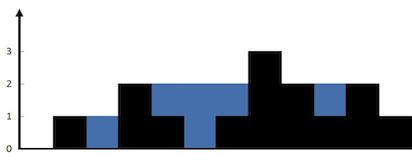

Input: height = [0,1,0,2,1,0,1,3,2,1,2,1]
Output: 6
Explanation: The above elevation map (black section) is represented by array [0,1,0,2,1,0,1,3,2,1,2,1]. In this case, 6 units of rain water (blue section) are being trapped.

## Leetcode 84. Largest Rectangle in Histogram (Hard)

Given an array of integers heights representing the histogram's bar height where the width of each bar is 1, return the area of the largest rectangle in the histogram.

- Example 1:

Input: heights = [2,1,5,6,2,3]
Output: 10
Explanation: The above is a histogram where width of each bar is 1.
The largest rectangle is shown in the red area, which has an area = 10 units.

- Example 2:

Input: heights = [2,4]
Output: 4

# Stack Application

- 栈的模拟
- 括号的匹配

## Leetcode 1544. Make The String Great
Given a string s of lower and upper case English letters.

A good string is a string which doesn't have two adjacent characters s[i] and s[i + 1] where:

0 <= i <= s.length - 2
s[i] is a lower-case letter and s[i + 1] is the same letter but in upper-case or vice-versa.
To make the string good, you can choose two adjacent characters that make the string bad and remove them. You can keep doing this until the string becomes good.

Return the string after making it good. The answer is guaranteed to be unique under the given constraints.

Notice that an empty string is also good.

- Example 1:

Input: s = "leEeetcode"
Output: "leetcode"
Explanation: In the first step, either you choose i = 1 or i = 2, both will result "leEeetcode" to be reduced to "leetcode".
- Example 2:

Input: s = "abBAcC"
Output: ""
Explanation: We have many possible scenarios, and all lead to the same answer. For example:
"abBAcC" --> "aAcC" --> "cC" --> ""
"abBAcC" --> "abBA" --> "aA" --> ""
- Example 3:

Input: s = "s"
Output: "s"

## Leetcode 71. Simplify Path (Medium)

You are given an absolute path for a Unix-style file system, which always begins with a slash '/'. Your task is to transform this absolute path into its simplified canonical path.

The rules of a Unix-style file system are as follows:

A single period '.' represents the current directory.
A double period '..' represents the previous/parent directory.
Multiple consecutive slashes such as '//' and '///' are treated as a single slash '/'.
Any sequence of periods that does not match the rules above should be treated as a valid directory or file name. For example, '...' and '....' are valid directory or file names.
The simplified canonical path should follow these rules:

The path must start with a single slash '/'.
Directories within the path must be separated by exactly one slash '/'.
The path must not end with a slash '/', unless it is the root directory.
The path must not have any single or double periods ('.' and '..') used to denote current or parent directories.
Return the simplified canonical path.

- Example 1:

Input: path = "/home/"

Output: "/home"

Explanation: The trailing slash should be removed.

- Example 2:

Input: path = "/home//foo/"

Output: "/home/foo"

Explanation:Multiple consecutive slashes are replaced by a single one.

- Example 3:

Input: path = "/home/user/Documents/../Pictures"

Output: "/home/user/Pictures"

Explanation: A double period ".." refers to the directory up a level (the parent directory).

- Example 4:

Input: path = "/../"

Output: "/"

Explanation:Going one level up from the root directory is not possible.

- Example 5:

Input: path = "/.../a/../b/c/../d/./"

Output: "/.../b/d"

Explanation: "..." is a valid name for a directory in this problem.

## Leetcode 1047. Remove All Adjacent Duplicates In String

Description:
Given a string S of lowercase letters, a duplicate removal consists of choosing two adjacent and equal letters, and removing them.
We repeatedly make duplicate removals on S until we no longer can.

Return the final string after all such duplicate removals have been made. It is guaranteed the answer is unique.

Note:
<= S.length <= 20000.
consists only of English lowercase letters.

- Example 1:

Input: s = "abbaca"
Output: "ca"
Explanation: 
For example, in "abbaca" we could remove "bb" since the letters are adjacent and equal, and this is the only possible move.  The result of this move is that the string is "aaca", of which only "aa" is possible, so the final string is "ca".
- Example 2:

Input: s = "azxxzy"
Output: "ay"

In [32]:
def removeAllAdj(string):
    stack = []
    for s in string:
        if stack and stack[-1] == s:
            stack.pop()
        else:
            stack.append(s)
    return ''.join(stack)

In [33]:
removeAllAdj("abbaca")

'ca'

In [34]:
removeAllAdj("azxxzy")

'ay'

In [16]:
def removeAllAdj(s):
    stack = []
    for a in s:
        if stack and stack[-1] == a:
            stack.pop()
        else:
            stack.append(a)
    return ''.join(stack)

In [17]:
removeAllAdj("abbaca")

'ca'

In [18]:
removeAllAdj("azxxzy")

'ay'

In [7]:
def removeAllAdj(string):
    stack = []
    for c in string:
        if len(stack) > 0 and stack[-1] == c:
            stack.pop()
        else:
            stack.append(c)
            
    return ''.join(stack)

In [8]:
removeAllAdj("abbaca")

'ca'

## Leetcode 1021. Remove Outermost Parentheses

A valid parentheses string is either empty "", "(" + A + ")", or A + B, where A and B are valid parentheses strings, and + represents string concatenation.

For example, "", "()", "(())()", and "(()(()))" are all valid parentheses strings.
A valid parentheses string s is primitive if it is nonempty, and there does not exist a way to split it into s = A + B, with A and B nonempty valid parentheses strings.

Given a valid parentheses string s, consider its primitive decomposition: s = P1 + P2 + ... + Pk, where Pi are primitive valid parentheses strings.

Return s after removing the outermost parentheses of every primitive string in the primitive decomposition of s.

- Example 1:

Input: s = "(()())(())", Output: "()()()"

Explanation: 
The input string is "(()())(())", with primitive decomposition "(()())" + "(())".
After removing outer parentheses of each part, this is "()()" + "()" = "()()()".

- Example 2:

Input: s = "(()())(())(()(()))", Output: "()()()()(())"

Explanation: 
The input string is "(()())(())(()(()))", with primitive decomposition "(()())" + "(())" + "(()(()))".
After removing outer parentheses of each part, this is "()()" + "()" + "()(())" = "()()()()(())".

- Example 3:

Input: s = "()()", Output: ""

Explanation: 
The input string is "()()", with primitive decomposition "()" + "()".
After removing outer parentheses of each part, this is "" + "" = "".

In [40]:
def removeOutermostParentheses(string):
    stack = []
    result = []
    for s in string:
        if s == '(':
            if stack:
                result.append(s)
            stack.append(s)
        elif s == ')':
            stack.pop()
            if stack:
                result.append(s)
    return ''.join(result)

In [41]:
removeOutermostParentheses("(()())(())")

'()()()'

In [42]:
removeOutermostParentheses("(()())(())(()(()))")

'()()()()(())'

In [39]:
removeOutermostParentheses("()()")

''

In [19]:
def removeOutermostParentheses(string):
    stack =[]
    cnt = 0
    for s in string:
        if s == '(':
            cnt += 1
            if cnt > 1:
                stack.append(s)
        else:
            cnt -= 1
            if cnt > 0:
                stack.append(s)
    return ''.join(stack)
        

In [20]:
removeOutermostParentheses("(()())(())")

'()()()'

In [21]:
removeOutermostParentheses("(()())(())(()(()))")

'()()()()(())'

In [22]:
removeOutermostParentheses("()()")

''

In [27]:
removeOutermostParentheses("(()())(())")

'()()()'

In [28]:
removeOutermostParentheses("(()())(())(()(()))")

'()()()()(())'

In [29]:
removeOutermostParentheses("()()")

''

## Leetcode 20. Valid Parentheses

Description:
Given a string containing just the characters "(", ")", "{", "}", "[" and "]", determine if the input string is valid.

An input string is valid if:

Open brackets must be closed by the same type of brackets.
Open brackets must be closed in the correct order.
Note:
That an empty string is also considered valid.

- Example1:
Input: "( )" Output: true

- Example2:
Input: "( ) [ ] { }" Output: true

- Example3:
Input: "( ]" Output: false

- Example4:
Input: "( [ ) ]" Output: false

- Example5:
Input: "{ [ ] }" Output: true

In [43]:
def validParentheses(string):
    myDict = {')':'(',']':'[','}':'{'}
    stack = []
    for s in string:
        if s in myDict:
            if stack and stack[-1] == myDict[s]:
                stack.pop()
        elif s in myDict.values():
            stack.append(s)
    if stack:
        return False
    else:
        return True

In [44]:
validParentheses("()")

True

In [45]:
validParentheses("()[]{}")

True

In [46]:
validParentheses("([)]")

False

In [47]:
validParentheses("{[]}")

True

In [23]:
def validParentheses(string):
    stack=[]
    myDict = {')':'(', ']':'[', '}':'{'}
    for s in string:
        if s in myDict:
            if stack and stack[-1] == myDict[s]:
                stack.pop()
        else:
            stack.append(s)
    if stack:
        return False
    else:
        return True

In [26]:
validParentheses("()")

True

In [28]:
validParentheses("()[]{}")

True

In [29]:
validParentheses("([)]")

False

In [30]:
validParentheses("{[]}")

True

In [37]:
def validParentheses(string):
    myDict = {')':'(', ']':'[', '}':'{'}
    stack = []
    for c in string:
        if c in myDict.values():
            stack.append(c)
        elif c in myDict:
            if len(stack) > 0 and stack[-1] == myDict[c]:
                stack.pop()
            elif len(stack) > 0 and stack[-1] != myDict[c]:
                return False
        elif c in [' ']:
            continue
    return len(stack) == 0
            

In [38]:
validParentheses("()")

True

In [39]:
validParentheses("( ) [ ] { }")

True

In [40]:
validParentheses("([)]")

False

In [41]:
validParentheses("{ [ ] }")

True

## Leetcode 1249. Minimum Remove to Make Valid Parentheses(Medium)

Given a string s of '(' , ')' and lowercase English characters.

Your task is to remove the minimum number of parentheses ( '(' or ')', in any positions ) so that the resulting parentheses string is valid and return any valid string.

Formally, a parentheses string is valid if and only if:

It is the empty string, contains only lowercase characters, or
It can be written as AB (A concatenated with B), where A and B are valid strings, or
It can be written as (A), where A is a valid string.
 
- Example 1:

Input: s = "lee(t(c)o)de)"
Output: "lee(t(c)o)de"
Explanation: "lee(t(co)de)" , "lee(t(c)ode)" would also be accepted.
- Example 2:

Input: s = "a)b(c)d"
Output: "ab(c)d"
- Example 3:

Input: s = "))(("
Output: ""
Explanation: An empty string is also valid.

## Leetcode 32. Longest Valid Parentheses (Hard)

Given a string containing just the characters '(' and ')', return the length of the longest valid (well-formed) parentheses substring.

- Example 1:

Input: s = "(()"
Output: 2
Explanation: The longest valid parentheses substring is "()".

- Example 2:

Input: s = ")()())"
Output: 4
Explanation: The longest valid parentheses substring is "()()".

- Example 3:

Input: s = ""
Output: 0

In [ ]:
myStack = MyStack()
myStack.push(1)
myStack.push(2)
myStack.top()

In [ ]:
myStack.pop()

In [ ]:
myStack.empty()

In [102]:
from collections import deque
class MyStack:
    def __init__(self):
        self.queue1 = deque()
        self.queue2 = deque()
    def push(self, num):
        self.queue2.append(num)
        while self.queue1:
            self.queue2.append(self.queue1.popleft())
        self.queue1, self.queue2 = self.queue2, self.queue1
    def top(self):
        return self.queue1[0]
    def pop(self):
        return self.queue1.popleft()        
    def empty(self):
        return len(self.queue1) == 0

In [103]:
myStack = MyStack()
myStack.push(1)
myStack.push(2)
myStack.top()

In [105]:
myStack.pop()

2

In [106]:
myStack.empty()

False

## Leetcode 682. Baseball Game

Description:
You’re now a baseball game point recorder.
Given a list of strings, each string can be one of the 4 following types:

Integer (one round’s score): Directly represents the number of points you get in this round.
"+" (one round’s score): Represents that the points you get in this round are the sum of the last two valid round’s points.
"D" (one round’s score): Represents that the points you get in this round are the doubled data of the last valid round’s points.
"C" (an operation, which isn’t a round’s score): Represents the last valid round’s points you get were invalid and should be removed.
Each round’s operation is permanent and could have an impact on the round before and the round after.

You need to return the sum of the points you could get in all the rounds.

Note:
The size of the input list will be between 1 and 1000.
Every integer represented in the list will be between -30000 and 30000.
Example1:
Input: ["5","2","C","D","+"]
Output: 30

Explanation:

Round 1: You could get 5 points. The sum is: 5.
Round 2: You could get 2 points. The sum is: 7.
Operation 1: The round 2’s data was invalid. The sum is: 5.
Round 3: You could get 10 points (the round 2’s data has been removed). The sum is: 15.
Round 4: You could get 5 + 10 = 15 points. The sum is: 30.

- Example2:
Input: ["5","-2","4","C","D","9","+","+"]
Output: 27

Explanation:

- Round 1: You could get 5 points. The sum is: 5.
- Round 2: You could get -2 points. The sum is: 3.
- Round 3: You could get 4 points. The sum is: 7.
    Operation 1: The round 3’s data is invalid. The sum is: 3.
- Round 4: You could get -4 points (the round 3’s data has been removed). The sum is: -1.
- Round 5: You could get 9 points. The sum is: 8.
- Round 6: You could get -4 + 9 = 5 points. The sum is 13.
- Round 7: You could get 9 + 5 = 14 points. The sum is 27.


In [9]:
def baseballGame(nums):
    stack = []
    result = 0
    for num in nums:
        if num[0] == '-':
            result += int(num)
            stack.append(int(num))
        elif num.isdigit():
            result += int(num)
            stack.append(int(num))
        elif num =='C':            
            result -= stack.pop()
        elif num == 'D':
            n = stack[-1]
            stack.append(2*n)
            result += 2*n
        elif num == '+':
            n = stack[-1] + stack[-2]
            stack.append(n)
            result += n
    return result 

In [10]:
baseballGame(["5","2","C","D","+"])

5
7
5
15
30


30

In [11]:
baseballGame(["5","-2","4","C","D","9","+","+"])

5
3
7
3
-1
8
13
27


27

In [75]:
def baseballGame(strList):
    result = 0
    stack = []
    for s in strList:
        if s[0]=='-':
            num = int(s)
            stack.append(num)
            result += num
        elif s.isdigit():
            num = int(s)
            stack.append(num)
            result += num
        elif s == 'D':
            num = stack[-1]*2
            stack.append(num)
            result += num
        elif s == 'C':
            num = stack.pop()
            result -= num
        elif s == '+':
            num1 = stack[-1]
            num2 = stack[-2]
            total = num1+num2
            result += total
            stack.append(total)
    return result

In [76]:
baseballGame(["5","2","C","D","+"])

30

In [77]:
baseballGame(["5","-2","4","C","D","9","+","+"])

27

In [67]:
def baseballGame(slist):
    stack = []
    result = 0
    for s in slist:
        
        if s.isnumeric():
            result += int(s)
            stack.append(int(s))
        elif s[0]=='-':
            result += int(s)
            stack.append(int(s))
        elif s == 'C' and len(stack) > 0:
            num = stack.pop()
            result -= num
        elif s == 'D' and len(stack) > 0:
            num = stack[-1] * 2
            stack.append(num)
            result += num
        elif s == '+' and len(stack) > 1:
            num1 = stack[-1]
            num2 = stack[-2]
            result += (num1+num2)
            stack.append(num1+num2)

    return result

In [68]:
baseballGame(["5","2","C","D","+"])

30

In [69]:
baseballGame(["5","-2","4","C","D","9","+","+"])

27

## Leetcode 844. Backspace String Compare

Description:
Given two strings S and T, return if they are equal when both are typed into empty text editors. # means a backspace character.

Note that after backspacing an empty text, the text will continue empty.

Note:
1 <= S.length <= 200
1 <= T.length <= 200
S and T only contain lowercase letters and "#" characters.

- Example1:
Input: S = "ab#c", T = "ad#c"
Output: true

Explanation: Both S and T become "ac".

- Example2:
Input: S = "ab##", T = "c#d#"
Output: true

Explanation: Both S and T become "".

- Example3:
Input: S = "a##c", T = "#a#c"
Output: true

Explanation: Both S and T become "c".

- Example4:
Input: S = "a#c", T = "b"
Output: false

Explanation: S becomes "c" while T becomes "b".

Follow up:
Can you solve it in O(N) time and O(1) space?

In [12]:
def backspaceStringCompare(S, T):
    stack1 = []
    stack2 = []
    for a in S:
        if a == '#':
            stack1.pop()
        else:
            stack1.append(a)
    for b in T:
        if b == '#':
            stack2.pop()
        else:
            stack2.append(b)
    return stack1 == stack2
        

In [13]:
backspaceStringCompare("ab#c", "ad#c")

True

In [14]:
backspaceStringCompare("ab##", "c#d#")

True

In [15]:
backspaceStringCompare("a#c", "b")

False

In [79]:
def backspaceStringCompare(s, t):
    stack1 = []
    stack2 = []
    for a in s:
        if a == '#':
            if stack1:
                stack1.pop()
        else:
            stack1.append(a)
    for b in t:
        if b == '#':
            if stack2:
                stack2.pop()
        else:
            stack2.append(b)
    return stack1 == stack2
    

In [80]:
backspaceStringCompare("ab#c", "ad#c")

True

In [81]:
backspaceStringCompare("ab##", "c#d#")

True

In [82]:
backspaceStringCompare("a#c", "b")

False

In [46]:
def backspaceStringCompare(s, t):
    stack1 = []
    stack2 = []
    for c in s:
        if len(stack1) >0 and c == '#':
            stack1.pop()
        elif c != '#':
            stack1.append(c)
    for c in t:
        if len(stack2) >0 and c == '#':
            stack2.pop()
        elif c != '#':
            stack2.append(c)
    return ''.join(stack1) == ''.join(stack2)

In [47]:
backspaceStringCompare("ab#c", "ad#c")

True

In [49]:
backspaceStringCompare("ab##", "c#d#")

True

In [48]:
backspaceStringCompare("a#c", "b")

False

In [96]:
class RecentCounter():
    def __init__(self):
        self.queue = deque()
    def ping(self, num):
        self.queue.append(num)
        if self.queue[0] < num - 3000:
            self.queue.popleft()        
        return len(self.queue)
            

In [97]:
counter = RecentCounter()
counter.ping(1)

1

In [98]:
counter.ping(100)

2

In [99]:
counter.ping(3001)

3

In [100]:
counter.ping(3002)

3

## Leetcode 394. Decode String (Medium)

Description:
Given an encoded string, return its decoded string.

The encoding rule is: k[encoded_string], where the encoded_string inside the square brackets is being repeated exactly k times. 
Note that k is guaranteed to be a positive integer.

ou may assume that the input string is always valid; No extra white spaces, square brackets are well-formed, etc.

Furthermore, you may assume that the original data does not contain any digits and that digits are only for those repeat numbers, k. 
For example, there won’t be input like 3a or 2[4].

- Example 1:

Input: s = "3[a]2[bc]"
Output: "aaabcbc"

- Example 2:
Input: s = "3[a2[c]]"
Output: "accaccacc"

- Example 3:
Input: s = "2[abc]3[cd]ef"
Output: "abcabccdcdcdef"

- Example 4:
Input: s = "abc3[cd]xyz"
Output: "abccdcdcdxyz"

In [ ]:
encodeString('3[a]2[bc]')

In [ ]:
encodeString('2[abc]3[cd]ef')

In [ ]:
encodeString('3[a2[c]]')

## Leetcode 1003. Check If Word Is Valid After Substitutions (Medium)

Given a string s, determine if it is valid.

A string s is valid if, starting with an empty string t = "", you can transform t into s after performing the following operation any number of times:

Insert string "abc" into any position in t. More formally, t becomes tleft + "abc" + tright, where t == tleft + tright. Note that tleft and tright may be empty.
Return true if s is a valid string, otherwise, return false.

- Example 1:

Input: s = "aabcbc"
Output: true

Explanation:
"" -> "abc" -> "aabcbc"
Thus, "aabcbc" is valid.
- Example 2:

Input: s = "abcabcababcc"
Output: true

Explanation:
"" -> "abc" -> "abcabc" -> "abcabcabc" -> "abcabcababcc"
Thus, "abcabcababcc" is valid.
- Example 3:

Input: s = "abccba"
Output: false

Explanation: It is impossible to get "abccba" using the operation.

## Leetcode 946. Validate Stack Sequences (Medium)
Given two integer arrays pushed and popped each with distinct values, return true if this could have been the result of a sequence of push and pop operations on an initially empty stack, or false otherwise.

- Example 1:

Input: pushed = [1,2,3,4,5], popped = [4,5,3,2,1]
Output: true
Explanation: We might do the following sequence:
push(1), push(2), push(3), push(4),
pop() -> 4,
push(5),
pop() -> 5, pop() -> 3, pop() -> 2, pop() -> 1
- Example 2:

Input: pushed = [1,2,3,4,5], popped = [4,3,5,1,2]
Output: false
Explanation: 1 cannot be popped before 2.

## Leetcode 1441. Build an Array With Stack Operations (Medium)

Description:
Given an array target and an integer n. In each iteration, you will read a number from list = {1,2,3..., n}.
Build the target array using the following operations:

Push: Read a new element from the beginning list, and push it in the array.
Pop: delete the last element of the array.
If the target array is already built, stop reading more elements.
You are guaranteed that the target array is strictly increasing, only containing numbers between 1 to n inclusive.

Return the operations to build the target array.
You are guaranteed that the answer is unique.

Example1:
Input: target = [1,3], n = 3
Output: ["Push","Push","Pop","Push"]

Explanation:

Read number 1 and automatically push in the array -> [1]
Read number 2 and automatically push in the array then Pop it -> [1]
Read number 3 and automatically push in the array -> [1,3]

Example2:
Input: target = [1,2,3], n = 3
Output: ["Push","Push","Push"]

Example3:
Input: target = [1,2], n = 4
Output: ["Push","Push"]

Explanation:

You only need to read the first 2 numbers and stop.

Example4:
Input: target = [2,3,4], n = 4
Output: ["Push","Pop","Push","Push","Push"]

Constraints:
1 <= target.length <= 100
1 <= target[i] <= 100
1 <= n <= 100
target is strictly increasing.

In [ ]:
# print(stackOperation([1,2,3],3))
# print(stackOperation([1,2],4))
# print(stackOperation([2,3,4],4))

## Leetcode 150. Evaluate Reverse Polish Notation (Medium)

You are given an array of strings tokens that represents an arithmetic expression in a Reverse Polish Notation.

Evaluate the expression. Return an integer that represents the value of the expression.

Note that:

The valid operators are '+', '-', '*', and '/'.
Each operand may be an integer or another expression.
The division between two integers always truncates toward zero.
There will not be any division by zero.
The input represents a valid arithmetic expression in a reverse polish notation.
The answer and all the intermediate calculations can be represented in a 32-bit integer.


- Example 1:

Input: tokens = ["2","1","+","3","*"]
Output: 9
Explanation: ((2 + 1) * 3) = 9

- Example 2:

Input: tokens = ["4","13","5","/","+"]
Output: 6
Explanation: (4 + (13 / 5)) = 6

- Example 3:

Input: tokens = ["10","6","9","3","+","-11","*","/","*","17","+","5","+"]
Output: 22
Explanation: ((10 * (6 / ((9 + 3) * -11))) + 17) + 5
= ((10 * (6 / (12 * -11))) + 17) + 5
= ((10 * (6 / -132)) + 17) + 5
= ((10 * 0) + 17) + 5
= (0 + 17) + 5
= 17 + 5
= 22

## Leetcode 402. Remove K Digits (Medium)
Given string num representing a non-negative integer num, and an integer k, return the smallest possible integer after removing k digits from num.

- Example 1:

Input: num = "1432219", k = 3
Output: "1219"

Explanation: Remove the three digits 4, 3, and 2 to form the new number 1219 which is the smallest.
- Example 2:

Input: num = "10200", k = 1
Output: "200"

Explanation: Remove the leading 1 and the number is 200. Note that the output must not contain leading zeroes.
- Example 3:

Input: num = "10", k = 2
Output: "0"

Explanation: Remove all the digits from the number and it is left with nothing which is 0.

## Leetcode 394. Decode String (Medium)
Given an encoded string, return its decoded string.

The encoding rule is: k[encoded_string], where the encoded_string inside the square brackets is being repeated exactly k times. Note that k is guaranteed to be a positive integer.

You may assume that the input string is always valid; there are no extra white spaces, square brackets are well-formed, etc. Furthermore, you may assume that the original data does not contain any digits and that digits are only for those repeat numbers, k. For example, there will not be input like 3a or 2[4].

The test cases are generated so that the length of the output will never exceed 105.
- Example 1:

Input: s = "3[a]2[bc]"
Output: "aaabcbc"
- Example 2:

Input: s = "3[a2[c]]"
Output: "accaccacc"
- Example 3:

Input: s = "2[abc]3[cd]ef"
Output: "abcabccdcdcdef"

## Leetcode 856. Score of Parentheses (Medium)

Given a balanced parentheses string s, return the score of the string.

The score of a balanced parentheses string is based on the following rule:

"()" has score 1.
AB has score A + B, where A and B are balanced parentheses strings.
(A) has score 2 * A, where A is a balanced parentheses string.
 

- Example 1:

Input: s = "()"
Output: 1
- Example 2:

Input: s = "(())"
Output: 2
- Example 3:

Input: s = "()()"
Output: 2

## Leetcode 227. Basic Calculator II (Medium)

Given a string s which represents an expression, evaluate this expression and return its value. 

The integer division should truncate toward zero.

You may assume that the given expression is always valid. All intermediate results will be in the range of [-231, 231 - 1].

Note: You are not allowed to use any built-in function which evaluates strings as mathematical expressions, such as eval().

- Example 1:

Input: s = "3+2*2"
Output: 7
- Example 2:

Input: s = " 3/2 "
Output: 1
- Example 3:

Input: s = " 3+5 / 2 "
Output: 5

## Leetcode 907. Sum of Subarray Minimums (Medium)

Given an array of integers arr, find the sum of min(b), where b ranges over every (contiguous) subarray of arr. Since the answer may be large, return the answer modulo $10^9 + 7$.

- Example 1:

Input: arr = [3,1,2,4]
Output: 17

Explanation: 
Subarrays are [3], [1], [2], [4], [3,1], [1,2], [2,4], [3,1,2], [1,2,4], [3,1,2,4]. 
Minimums are 3, 1, 2, 4, 1, 1, 2, 1, 1, 1.
Sum is 17.

- Example 2:

Input: arr = [11,81,94,43,3]
Output: 444

In [ ]:
def sumSubMin(arr):

In [ ]:
arr = [3,1,2,4]
sumSubMin(arr)

In [ ]:
arr = [11,81,94,43,3]
sumSubMin(arr)

## Leetcode 2390. Removing Stars From a String(Medium)

You are given a string s, which contains stars *.

In one operation, you can:

Choose a star in s.
Remove the closest non-star character to its left, as well as remove the star itself.
Return the string after all stars have been removed.

Note:

The input will be generated such that the operation is always possible.
It can be shown that the resulting string will always be unique.
 

- Example 1:

Input: s = "leet**cod*e"
Output: "lecoe"
Explanation: Performing the removals from left to right:
- The closest character to the 1st star is 't' in "leet**cod*e". s becomes "lee*cod*e".
- The closest character to the 2nd star is 'e' in "lee*cod*e". s becomes "lecod*e".
- The closest character to the 3rd star is 'd' in "lecod*e". s becomes "lecoe".
There are no more stars, so we return "lecoe".
- Example 2:

Input: s = "erase*****"
Output: ""
Explanation: The entire string is removed, so we return an empty string.

## Leetcode 2434. Using a Robot to Print the Lexicographically Smallest String(Medium)

You are given a string s and a robot that currently holds an empty string t. Apply one of the following operations until s and t are both empty:

Remove the first character of a string s and give it to the robot. The robot will append this character to the string t.
Remove the last character of a string t and give it to the robot. The robot will write this character on paper.
Return the lexicographically smallest string that can be written on the paper.

- Example 1:

Input: s = "zza"
Output: "azz"
Explanation: Let p denote the written string.
Initially p="", s="zza", t="".
Perform first operation three times p="", s="", t="zza".
Perform second operation three times p="azz", s="", t="".
- Example 2:

Input: s = "bac"
Output: "abc"
Explanation: Let p denote the written string.
Perform first operation twice p="", s="c", t="ba". 
Perform second operation twice p="ab", s="c", t="". 
Perform first operation p="ab", s="", t="c". 
Perform second operation p="abc", s="", t="".
- Example 3:

Input: s = "bdda"
Output: "addb"
Explanation: Let p denote the written string.
Initially p="", s="bdda", t="".
Perform first operation four times p="", s="", t="bdda".
Perform second operation four times p="addb", s="", t="".

## Leetcode 1717. Maximum Score From Removing Substrings(Medium)

You are given a string s and two integers x and y. You can perform two types of operations any number of times.

Remove substring "ab" and gain x points.
For example, when removing "ab" from "cabxbae" it becomes "cxbae".
Remove substring "ba" and gain y points.
For example, when removing "ba" from "cabxbae" it becomes "cabxe".
Return the maximum points you can gain after applying the above operations on s.

- Example 1:

Input: s = "cdbcbbaaabab", x = 4, y = 5
Output: 19

Explanation:
- Remove the "ba" underlined in "cdbcbbaaabab". Now, s = "cdbcbbaaab" and 5 points are added to the score.
- Remove the "ab" underlined in "cdbcbbaaab". Now, s = "cdbcbbaa" and 4 points are added to the score.
- Remove the "ba" underlined in "cdbcbbaa". Now, s = "cdbcba" and 5 points are added to the score.
- Remove the "ba" underlined in "cdbcba". Now, s = "cdbc" and 5 points are added to the score.
Total score = 5 + 4 + 5 + 5 = 19.
- Example 2:

Input: s = "aabbaaxybbaabb", x = 5, y = 4
Output: 20

## Leetcode 1653. Minimum Deletions to Make String Balanced (Medium)

You are given a string s consisting only of characters 'a' and 'b'.

You can delete any number of characters in s to make s balanced. s is balanced if there is no pair of indices (i,j) such that i < j and s[i] = 'b' and s[j]= 'a'.

Return the minimum number of deletions needed to make s balanced.

- Example 1:

Input: s = "aababbab"
Output: 2

Explanation: You can either:
Delete the characters at 0-indexed positions 2 and 6 ("aababbab" -> "aaabbb"), or
Delete the characters at 0-indexed positions 3 and 6 ("aababbab" -> "aabbbb").
- Example 2:

Input: s = "bbaaaaabb"
Output: 2

Explanation: The only solution is to delete the first two characters.

## Leetcode 2345. Finding the Number of Visible Mountains

You are given a 0-indexed 2D integer array peaks where peaks[i] = [xi, yi] states that mountain i has a peak at coordinates (xi, yi). A mountain can be described as a right-angled isosceles triangle, with its base along the x-axis and a right angle at its peak. More formally, the gradients of ascending and descending the mountain are 1 and -1 respectively.

A mountain is considered visible if its peak does not lie within another mountain (including the border of other mountains).

Return the number of visible mountains.

- Example 1

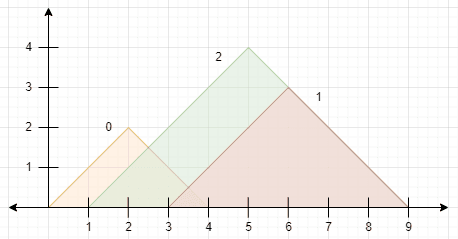

Input: peaks = [[2,2],[6,3],[5,4]]
Output: 2
Explanation: The diagram above shows the mountains.
- Mountain 0 is visible since its peak does not lie within another mountain or its sides.
- Mountain 1 is not visible since its peak lies within the side of mountain 2.
- Mountain 2 is visible since its peak does not lie within another mountain or its sides.
There are 2 mountains that are visible.

- Example 2

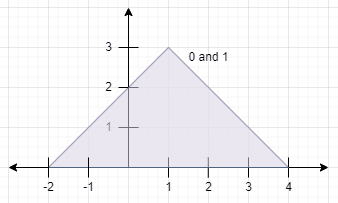

Input: peaks = [[1,3],[1,3]]
Output: 0
Explanation: The diagram above shows the mountains (they completely overlap).
Both mountains are not visible since their peaks lie within each other.

## Leetcode 895. Maximum Frequency Stack (Hard)
Design a stack-like data structure to push elements to the stack and pop the most frequent element from the stack.

Implement the FreqStack class:

FreqStack() constructs an empty frequency stack.
void push(int val) pushes an integer val onto the top of the stack.
int pop() removes and returns the most frequent element in the stack.
If there is a tie for the most frequent element, the element closest to the stack's top is removed and returned.
 

- Example 1:

Input
["FreqStack", "push", "push", "push", "push", "push", "push", "pop", "pop", "pop", "pop"]
[[], [5], [7], [5], [7], [4], [5], [], [], [], []]
Output
[null, null, null, null, null, null, null, 5, 7, 5, 4]

Explanation
FreqStack freqStack = new FreqStack();
freqStack.push(5); // The stack is [5]
freqStack.push(7); // The stack is [5,7]
freqStack.push(5); // The stack is [5,7,5]
freqStack.push(7); // The stack is [5,7,5,7]
freqStack.push(4); // The stack is [5,7,5,7,4]
freqStack.push(5); // The stack is [5,7,5,7,4,5]
freqStack.pop();   // return 5, as 5 is the most frequent. The stack becomes [5,7,5,7,4].
freqStack.pop();   // return 7, as 5 and 7 is the most frequent, but 7 is closest to the top. The stack becomes [5,7,5,4].
freqStack.pop();   // return 5, as 5 is the most frequent. The stack becomes [5,7,4].
freqStack.pop();   // return 4, as 4, 5 and 7 is the most frequent, but 4 is closest to the top. The stack becomes [5,7].

## Leetcode 2296. Design a Text Editor(Hard)

Design a text editor with a cursor that can do the following:

Add text to where the cursor is.
Delete text from where the cursor is (simulating the backspace key).
Move the cursor either left or right.
When deleting text, only characters to the left of the cursor will be deleted. The cursor will also remain within the actual text and cannot be moved beyond it. More formally, we have that 0 <= cursor.position <= currentText.length always holds.

Implement the TextEditor class:

- TextEditor() Initializes the object with empty text.
- void addText(string text) Appends text to where the cursor is. The cursor ends to the right of text.
- int deleteText(int k) Deletes k characters to the left of the cursor. Returns the number of characters actually deleted.
- string cursorLeft(int k) Moves the cursor to the left k times. Returns the last min(10, len) characters to the left of the cursor, where len is the number of characters to the left of the cursor.
- string cursorRight(int k) Moves the cursor to the right k times. Returns the last min(10, len) characters to the left of the cursor, where len is the number of characters to the left of the cursor.


# Queue

## Leetcode 225. Implement Stack using Queues

Description:
Implement the following operations of a stack using queues.

push(x) -- Push element x onto stack.

pop() -- Removes the element on top of the stack.

top() -- Get the top element.

empty() -- Return whether the stack is empty.

- Example 1:

Input
["MyStack", "push", "push", "top", "pop", "empty"]
[[], [1], [2], [], [], []]

Output
[null, null, null, 2, 2, false]

Explanation

MyStack myStack = new MyStack();

myStack.push(1);

myStack.push(2);

myStack.top(); // return 2

myStack.pop(); // return 2

myStack.empty(); // return False

In [54]:
from collections import deque
class MyStack():
    def __init__(self):
        self.queue1 = deque()
        self.queue2 = deque()
    def push(self, num):
        self.queue1.append(num)
        while self.queue2:
            self.queue1.append(self.queue2.popleft())
        self.queue1, self.queue2,  = self.queue2, self.queue1
    def pop(self):
        return self.queue2.popleft()
    def top(self):
        return self.queue2[0]
    def empty(self):
        return len(self.queue2)==0

In [55]:
myStack = MyStack()
myStack.push(1)
myStack.push(2)
myStack.top()

2

In [56]:
myStack.pop()

2

In [57]:
myStack.empty()

False

## Leetcode 933. Number of Recent Calls

Description:
Write a class RecentCounter to count recent requests.

It has only one method: ping(int t), where t represents some time in milliseconds.

Return the number of pings that have been made from 3000 milliseconds ago until now.

Any ping with time in [t - 3000, t] will count, including the current ping.

It is guaranteed that every call to ping uses a strictly larger value of t than before.

Note:
Each test case will have at most 10000 calls to ping.
Each test case will call ping with strictly increasing values of t.
Each call to ping will have 1 <= t <= 10^9.

- Example 1:

Input
["RecentCounter", "ping", "ping", "ping", "ping"]
[[], [1], [100], [3001], [3002]]
Output
[null, 1, 2, 3, 3]

Explanation

RecentCounter recentCounter = new RecentCounter();

recentCounter.ping(1);     // requests = [1], range is [-2999,1], return 1

recentCounter.ping(100);   // requests = [1, 100], range is [-2900,100], return 2

recentCounter.ping(3001);  // requests = [1, 100, 3001], range is [1,3001], return 3

recentCounter.ping(3002);  // requests = [1, 100, 3001, 3002], range is [2,3002], return 3

In [20]:
from collections import deque
class RecentCounter():
    def __init__(self):
        self.queue = deque()
    def ping(self, num):
        lower = num - 3000
        higher = num
        self.queue.append(num)
        while self.queue[0] < lower:
            self.queue.popleft()
        return len(self.queue)

In [21]:
counter = RecentCounter()
counter.ping(1)

1

In [22]:
counter.ping(100)

2

In [23]:
counter.ping(3001)

3

In [24]:
counter.ping(3002)

3

# Two headed Queue

## Leetcode 239. Sliding Window Maximum (Hard)

You are given an array of integers nums, there is a sliding window of size k which is moving from the very left of the array to the very right. You can only see the k numbers in the window. Each time the sliding window moves right by one position.

Return the max sliding window.

 

- Example 1:

Input: nums = [1,3,-1,-3,5,3,6,7], k = 3
Output: [3,3,5,5,6,7]
Explanation: 
Window position                Max
---------------               -----
[1  3  -1] -3  5  3  6  7       3
 1 [3  -1  -3] 5  3  6  7       3
 1  3 [-1  -3  5] 3  6  7       5
 1  3  -1 [-3  5  3] 6  7       5
 1  3  -1  -3 [5  3  6] 7       6
 1  3  -1  -3  5 [3  6  7]      7
- Example 2:

Input: nums = [1], k = 1
Output: [1]